# Exploratory Data Analysis - 2020 Cloud Resource Data

This notebook performs EDA on the 2020 cloud resource optimization data from the PAI (Platform of Artificial Intelligence) dataset.

## 1. Import Required Libraries

In [43]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Configure plotting settings
%matplotlib inline
plt.style.use('ggplot')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Datasets

The 2020 data contains multiple CSV files:
- **pai_group_tag_table.csv**: Group and tag information
- **pai_instance_table.csv**: Instance details
- **pai_machine_metric.csv**: Machine performance metrics
- **pai_machine_spec.csv**: Machine specifications
- **pai_sensor_table.csv**: Sensor data
- **pai_task_table.csv**: Task information

In [44]:
# Define data directory
data_dir = Path(r'E:\Cloud_Resource_Optimisation_thesis\data\raw\data2020')

# Define column names for each table based on schema
group_tag_cols = ['inst_id', 'user', 'gpu_type_spec', 'group', 'workload']
instance_cols = ['job_name', 'task_name', 'inst_name', 'worker_name', 'inst_id', 
                 'status', 'start_time', 'end_time', 'machine']
machine_metric_cols = ['worker_name', 'machine', 'start_time', 'end_time', 
                       'machine_cpu_iowait', 'machine_cpu_kernel', 'machine_cpu_usr', 
                       'machine_gpu', 'machine_load_1', 'machine_net_receive', 
                       'machine_num_worker', 'machine_cpu']
machine_spec_cols = ['machine', 'gpu_type', 'cap_cpu', 'cap_mem', 'cap_gpu']
sensor_cols = ['job_name', 'task_name', 'worker_name', 'inst_id', 'machine', 'gpu_name',
               'cpu_usage', 'gpu_wrk_util', 'avg_mem', 'max_mem', 'avg_gpu_wrk_mem', 
               'max_gpu_wrk_mem', 'read', 'write', 'read_count', 'write_count']
task_cols = ['job_name', 'task_name', 'inst_num', 'status', 'start_time', 'end_time',
             'plan_cpu', 'plan_mem', 'plan_gpu', 'gpu_type']

# Load all datasets with proper column names
print("Loading datasets...")
group_tag = pd.read_csv(data_dir / 'pai_group_tag_table.csv', names=group_tag_cols, header=None)
instance = pd.read_csv(data_dir / 'pai_instance_table.csv', names=instance_cols, header=None)
machine_metric = pd.read_csv(data_dir / 'pai_machine_metric.csv', names=machine_metric_cols, header=None)
machine_spec = pd.read_csv(data_dir / 'pai_machine_spec.csv', names=machine_spec_cols, header=None)
sensor = pd.read_csv(data_dir / 'pai_sensor_table.csv', names=sensor_cols, header=None)
task = pd.read_csv(data_dir / 'pai_task_table.csv', names=task_cols, header=None)

print("✓ All datasets loaded successfully!")
print(f"\nData directory: {data_dir}")

Loading datasets...
✓ All datasets loaded successfully!

Data directory: E:\Cloud_Resource_Optimisation_thesis\data\raw\data2020


## 3. Initial Data Inspection

Let's examine the structure of each dataset.

In [45]:
# Dataset overview
datasets = {
    'Group Tag': group_tag,
    'Instance': instance,
    'Machine Metric': machine_metric,
    'Machine Spec': machine_spec,
    'Sensor': sensor,
    'Task': task
}

print("Dataset Shapes:")
print("=" * 60)
for name, df in datasets.items():
    print(f"{name:20s}: {df.shape[0]:,} rows × {df.shape[1]} columns")
    
print("\n" + "=" * 60)

Dataset Shapes:
Group Tag           : 1,055,032 rows × 5 columns
Instance            : 7,522,002 rows × 9 columns
Machine Metric      : 2,009,423 rows × 12 columns
Machine Spec        : 1,897 rows × 5 columns
Sensor              : 3,033,232 rows × 16 columns
Task                : 1,261,050 rows × 10 columns



### 3.1 Group Tag Table

In [46]:
print("Group Tag Table - First 5 rows:")
display(group_tag.head())

print("\nColumn Information:")
group_tag.info()

print("\nData Types:")
print(group_tag.dtypes)

Group Tag Table - First 5 rows:


,inst_id,user,gpu_type_spec,group,workload
0,c1bdfdda2af739f74be81079cfe176800093c65907b3a9...,58540f191766,NaN,ba4e3be6472ded359f4b1ca53d9bd53e,NaN
1,a8c39faded8b9a5b7436a47aff747835795cec39ef33c7...,58540f191766,NaN,81b1eed4c4b0463b7e5a154f7c42db1e,NaN
2,26bf18df11f3a989fa64ed808dc780ab24a7700941f7c1...,58540f191766,NaN,046437ed700bdf7434aa88503cc97a8d,NaN
3,a4fdd0229b8fcc227a8828daaa37500a29e125c1c38d1c...,58540f191766,NaN,d50ee406f93d51ccf485b415861dd8f5,NaN
4,4b4ab6c2a0691b35d8a9abb22ade8164b6be1bdb19c8a7...,58540f191766,NaN,c5ee81877b36fdb5dac829aab7b4146a,NaN



Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 1055032 entries, 0 to 1055031
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   inst_id        1055032 non-null  str  
 1   user           1055031 non-null  str  
 2   gpu_type_spec  20633 non-null    str  
 3   group          1055032 non-null  str  
 4   workload       102798 non-null   str  
dtypes: str(5)
memory usage: 40.2 MB

Data Types:
inst_id          str
user             str
gpu_type_spec    str
group            str
workload         str
dtype: object


### 3.2 Instance Table

In [47]:
print("Instance Table - First 5 rows:")
display(instance.head())

print("\nColumn Information:")
instance.info()

print("\nData Types:")
print(instance.dtypes)

Instance Table - First 5 rows:


,job_name,task_name,inst_name,worker_name,inst_id,status,start_time,end_time,machine
0,54670e2998350a9f0e4868d5,worker,c47ee192deea8c5aa87d8d7c2e02120cd03f75304a69dd...,05b1590648df3f4c6deea2496bbbefd4d3ae93347669f7...,68889727c2257f702108d185e5eed342a39807a2893d4b...,Terminated,3272995.0,3273065.0,165261853e188ca69c4fbcdf
1,54670e2998350a9f0e4868d5,worker,92759a73039692b2d3e0929cadf55f5b07b40d6582c36f...,cbc1bc591c53301bceafa44dc626288fd92d2fc5dca438...,68889727c2257f702108d185e5eed342a39807a2893d4b...,Terminated,3272995.0,3273056.0,31dbf829549b10917e7193a6
2,54670e2998350a9f0e4868d5,worker,b3e42abde4c35da06ff4746802b82678b1bf56b28efaa1...,09d41bf627188adc004b2db7c0a47578325952cc3340af...,68889727c2257f702108d185e5eed342a39807a2893d4b...,Terminated,3272995.0,3273067.0,31dbf829549b10917e7193a6
3,54670e2998350a9f0e4868d5,worker,d0f2e1f76ff463bcd08302370cc2f9bf0ec1333a3b25e3...,1a631e8be3fd787c2891c15b9e9bac6df4f177efc9ec7b...,68889727c2257f702108d185e5eed342a39807a2893d4b...,Terminated,3272995.0,3273058.0,3765d45e2eca88d1d1da7cef
4,54670e2998350a9f0e4868d5,worker,0243b1305fd38f228634b23f69de5ed5ce801360eeffdc...,59aea81c00cccb5cd01ca2f7f72877d6bc73b427821986...,68889727c2257f702108d185e5eed342a39807a2893d4b...,Terminated,3272995.0,3273059.0,c0d6760f6248ea8260e36fa5



Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 7522002 entries, 0 to 7522001
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   job_name     str    
 1   task_name    str    
 2   inst_name    str    
 3   worker_name  str    
 4   inst_id      str    
 5   status       str    
 6   start_time   float64
 7   end_time     float64
 8   machine      str    
dtypes: float64(2), str(7)
memory usage: 516.5 MB

Data Types:
job_name           str
task_name          str
inst_name          str
worker_name        str
inst_id            str
status             str
start_time     float64
end_time       float64
machine            str
dtype: object


### 3.3 Machine Metric Table

In [48]:
print("Machine Metric Table - First 5 rows:")
display(machine_metric.head())

print("\nColumn Information:")
machine_metric.info()

print("\nData Types:")
print(machine_metric.dtypes)

Machine Metric Table - First 5 rows:


,worker_name,machine,start_time,end_time,machine_cpu_iowait,machine_cpu_kernel,machine_cpu_usr,machine_gpu,machine_load_1,machine_net_receive,machine_num_worker,machine_cpu
0,8fa54171acbc9f16704c03f137ac053ede9a97432cfc94...,5248e29b2b7f2b5f8b974608,2134401,2134599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9b69319eb5d19b4ea2514fcb4d761c3d00be925b65f529...,5248e29b2b7f2b5f8b974608,2806218,2806331,0.006080,9.226264,40.158927,192.551088,89.731273,3.845883e+08,15.672816,49.391271
2,b37cd5d848323f23352464f71d3c27ef4796532ee09d59...,5248e29b2b7f2b5f8b974608,3084090,3084411,0.000699,10.140853,40.807522,150.497242,72.377214,7.027994e+08,14.234469,50.949074
3,8a3db37b3795c7c753963d0ef966df9703d39b9f918e1a...,5248e29b2b7f2b5f8b974608,2119980,2134354,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,f114ac24745ec00da7107387afc99ed7cd8132530e8ef7...,5248e29b2b7f2b5f8b974608,2164803,2171278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 2009423 entries, 0 to 2009422
Data columns (total 12 columns):
 #   Column               Dtype  
---  ------               -----  
 0   worker_name          str    
 1   machine              str    
 2   start_time           int64  
 3   end_time             int64  
 4   machine_cpu_iowait   float64
 5   machine_cpu_kernel   float64
 6   machine_cpu_usr      float64
 7   machine_gpu          float64
 8   machine_load_1       float64
 9   machine_net_receive  float64
 10  machine_num_worker   float64
 11  machine_cpu          float64
dtypes: float64(8), int64(2), str(2)
memory usage: 184.0 MB

Data Types:
worker_name                str
machine                    str
start_time               int64
end_time                 int64
machine_cpu_iowait     float64
machine_cpu_kernel     float64
machine_cpu_usr        float64
machine_gpu            float64
machine_load_1         float64
machine_net_receive    float64
machine_num_worker

### 3.4 Machine Spec Table

In [49]:
print("Machine Spec Table - First 5 rows:")
display(machine_spec.head())

print("\nColumn Information:")
machine_spec.info()

print("\nData Types:")
print(machine_spec.dtypes)

Machine Spec Table - First 5 rows:


,machine,gpu_type,cap_cpu,cap_mem,cap_gpu
0,7399a758eb02bae1a3621236,CPU,96,512,0
1,75c536d5ba60528b3ef3ae40,CPU,96,512,0
2,6265a99de1a50cc6f1b03602,CPU,96,512,0
3,cb5c703eae0a123ad25e480d,CPU,96,512,0
4,fc6921f2af20c5337c43d4a9,CPU,96,512,0



Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 1897 entries, 0 to 1896
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   machine   1897 non-null   str  
 1   gpu_type  1897 non-null   str  
 2   cap_cpu   1897 non-null   int64
 3   cap_mem   1897 non-null   int64
 4   cap_gpu   1897 non-null   int64
dtypes: int64(3), str(2)
memory usage: 74.2 KB

Data Types:
machine       str
gpu_type      str
cap_cpu     int64
cap_mem     int64
cap_gpu     int64
dtype: object


### 3.5 Sensor Table

In [50]:
print("Sensor Table - First 5 rows:")
display(sensor.head())

print("\nColumn Information:")
sensor.info()

print("\nData Types:")
print(sensor.dtypes)

Sensor Table - First 5 rows:


,job_name,task_name,worker_name,inst_id,machine,gpu_name,cpu_usage,gpu_wrk_util,avg_mem,max_mem,avg_gpu_wrk_mem,max_gpu_wrk_mem,read,write,read_count,write_count
0,c6acdbd813439f3ca63a9406,worker,d50591d4a39b5a68e7efa15a0b51cfdca03e8f7a49ade7...,dc6e6daefec62bc3729def7e15133c03b82a97a1457d68...,4a57d4f3d41316da3c4ae876,/dev/nvidia5,0.603296,0.000000,0.232509,0.256836,0.000000,0.000000,4.666371e+03,6.608757e+03,50.706367,47.831054
1,c6acdbd813439f3ca63a9406,worker,fd1ee8bacf027604c2afdf89fc4edd843322b78376c9df...,dc6e6daefec62bc3729def7e15133c03b82a97a1457d68...,d84f5bc585e4ac5d24b30ec1,/dev/nvidia7,1.039332,0.000000,0.305684,0.343750,0.000000,0.000000,9.073576e+03,6.643213e+03,80.299497,47.311857
2,c6acdbd813439f3ca63a9406,worker,8885c53fd558926cb6aa44bbb7f40e242093778988c57d...,dc6e6daefec62bc3729def7e15133c03b82a97a1457d68...,b8dca09e0247ec64355414f9,/dev/nvidia2,0.287556,0.000000,0.345654,0.436523,0.000000,0.000000,4.852393e+03,6.681694e+03,50.627430,47.857114
3,3e4e9725920e7dc4a7a4ebdd,worker,8170c081a8d69cc228b9c2fa13a1c5e1190bf215296816...,ccc2b2c5742997e7ed0459efa6ec3db8b8e56e3f7fcd5f...,f7c1c4979c05bb7d20da65e4,/dev/nvidia7,83.771930,18.883333,5.817499,6.886719,2.065153,2.317383,1.504240e+08,5.082606e+07,7119.393443,75116.196721
4,3e4e9725920e7dc4a7a4ebdd,worker,e43f95191455f15365b40289c32b44648ce1e501331119...,ccc2b2c5742997e7ed0459efa6ec3db8b8e56e3f7fcd5f...,142a829a1e344f905fdcce42,/dev/nvidia2,112.711111,27.000000,5.494639,6.951172,2.001526,2.317383,1.854764e+08,6.311824e+07,9050.204082,93378.387755



Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 3033232 entries, 0 to 3033231
Data columns (total 16 columns):
 #   Column           Dtype  
---  ------           -----  
 0   job_name         str    
 1   task_name        str    
 2   worker_name      str    
 3   inst_id          str    
 4   machine          str    
 5   gpu_name         str    
 6   cpu_usage        float64
 7   gpu_wrk_util     float64
 8   avg_mem          float64
 9   max_mem          float64
 10  avg_gpu_wrk_mem  float64
 11  max_gpu_wrk_mem  float64
 12  read             float64
 13  write            float64
 14  read_count       float64
 15  write_count      float64
dtypes: float64(10), str(6)
memory usage: 370.3 MB

Data Types:
job_name               str
task_name              str
worker_name            str
inst_id                str
machine                str
gpu_name               str
cpu_usage          float64
gpu_wrk_util       float64
avg_mem            float64
max_mem            float64
avg

### 3.6 Task Table

In [51]:
print("Task Table - First 5 rows:")
display(task.head())

print("\nColumn Information:")
task.info()

print("\nData Types:")
print(task.dtypes)

Task Table - First 5 rows:


,job_name,task_name,inst_num,status,start_time,end_time,plan_cpu,plan_mem,plan_gpu,gpu_type
0,c936346f45eccd34bf748541,tensorflow,1.0,Terminated,2693235.0,2695847.0,600.0,29.296875,50.0,MISC
1,455c3dec270f4777ad67721c,tensorflow,1.0,Terminated,3399583.0,3399732.0,600.0,29.296875,100.0,MISC
2,ba64aa2f0feff18428923e92,tensorflow,1.0,Terminated,2152271.0,2158213.0,600.0,29.296875,50.0,MISC
3,704783be2a4b7f88b8d2e4ee,worker,100.0,Failed,2172980.0,NaN,600.0,9.765625,10.0,MISC
4,bce3b9c55772f9d1e85fe796,PyTorchWorker,4.0,Failed,2374681.0,NaN,400.0,10.000000,100.0,V100



Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 1261050 entries, 0 to 1261049
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   job_name    1261050 non-null  str    
 1   task_name   1261050 non-null  str    
 2   inst_num    1260920 non-null  float64
 3   status      1261050 non-null  str    
 4   start_time  1257336 non-null  float64
 5   end_time    911489 non-null   float64
 6   plan_cpu    1242596 non-null  float64
 7   plan_mem    1242596 non-null  float64
 8   plan_gpu    1037085 non-null  float64
 9   gpu_type    1043312 non-null  str    
dtypes: float64(6), str(4)
memory usage: 96.2 MB

Data Types:
job_name          str
task_name         str
inst_num      float64
status            str
start_time    float64
end_time      float64
plan_cpu      float64
plan_mem      float64
plan_gpu      float64
gpu_type          str
dtype: object


## 4. Statistical Summary

Generate descriptive statistics for all numerical columns in each dataset.

In [52]:
# Statistical summary for all datasets
for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(f"Statistical Summary: {name}")
    print('=' * 60)
    display(df.describe(include='all').T)
    print("\n")


Statistical Summary: Group Tag


,count,unique,top,freq
inst_id,1055032,1055032,c1bdfdda2af739f74be81079cfe176800093c65907b3a9...,1
user,1055031,1431,58540f191766,284992
gpu_type_spec,20633,5,P100,7653
group,1055032,316956,7755b21bfabe33c2399770fd4f3be0f9,22642
workload,102798,9,bert,54887





Statistical Summary: Instance


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_name,7522002,1055432,d429561ea0d5fec7914c299c,6330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
task_name,7522002,24,worker,5044871,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inst_name,7522002,6846883,e97bc8c475bd5606c3391082d0aea1a5029165539f5c6b...,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
worker_name,7190945,7164358,c4bcecef4ea7222186134645a6d6ca1f40786ee90da66d...,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inst_id,7522002,1055432,540f16ef6cf66008e607249a23b3c2d17f9b31239157e9...,6330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,7522002,6,Terminated,4757371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_time,5748534.0,NaN,NaN,NaN,3873839.411232,1556708.850488,494366.0,2509789.0,3909940.0,5284903.0,6451090.0
end_time,5254420.0,NaN,NaN,NaN,3924894.029838,1523082.966426,532768.0,2647343.25,4004698.5,5262644.0,6451192.0
machine,7190945,1897,07a757904c2974820f7f9dce,60239,NaN,NaN,NaN,NaN,NaN,NaN,NaN





Statistical Summary: Machine Metric


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
machine,1897,1897,7399a758eb02bae1a3621236,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gpu_type,1897,6,P100,798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap_cpu,1897.0,NaN,NaN,NaN,82.538745,15.801468,64.0,64.0,96.0,96.0,96.0
cap_mem,1897.0,NaN,NaN,NaN,499.854507,37.521357,384.0,512.0,512.0,512.0,512.0
cap_gpu,1897.0,NaN,NaN,NaN,3.554033,2.759211,0.0,2.0,2.0,8.0,8.0





Statistical Summary: Sensor


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_name,3033232,838678,f8ce59e595168642575b09a3,559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
task_name,3033232,14,worker,2263800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
worker_name,3033232,3033232,d50591d4a39b5a68e7efa15a0b51cfdca03e8f7a49ade7...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inst_id,3033232,838678,13a5baff2c71fe05b2617db8a34e8779ea6898458f6b51...,559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
machine,3033232,1737,851d52e9301aeafd051e2f2b,14781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gpu_name,3033232,8,/dev/nvidia1,854560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cpu_usage,3027403.0,NaN,NaN,NaN,258.83879,568.058227,0.0,57.2,103.493506,238.632885,9206.331084
gpu_wrk_util,3033232.0,NaN,NaN,NaN,10.451584,30.004374,0.0,0.0,1.466667,9.753623,792.0
avg_mem,3032015.0,NaN,NaN,NaN,5.542803,10.622978,0.0,0.732143,2.520953,6.420668,391.629133
max_mem,3033232.0,NaN,NaN,NaN,10.693113,57.706708,0.0,1.410156,3.819336,10.185547,2757.585938





Statistical Summary: Task


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_name,1261050,1055501,0183ce0be7b6bafe60f3cba4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
task_name,1261050,24,tensorflow,621415,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inst_num,1260920.0,NaN,NaN,NaN,5.430069,19.406736,1.0,1.0,1.0,1.0,1200.0
status,1261050,4,Terminated,885073,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_time,1257336.0,NaN,NaN,NaN,3995088.80165,1545314.249587,494319.0,2726390.25,4149047.5,5431610.25,6451081.0
end_time,911489.0,NaN,NaN,NaN,3907677.02609,1550822.148262,675318.0,2576197.0,4004431.0,5272397.0,6451192.0
plan_cpu,1242596.0,NaN,NaN,NaN,633.374114,591.508192,0.0,600.0,600.0,600.0,9000.0
plan_mem,1242596.0,NaN,NaN,NaN,28.361569,19.548993,0.003906,29.296875,29.296875,29.296875,400.0
plan_gpu,1037085.0,NaN,NaN,NaN,68.255292,74.258781,1.0,25.0,50.0,100.0,800.0
gpu_type,1043312,5,MISC,696281,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Missing Values Analysis

Identify and visualize missing values in all datasets.

In [53]:
# Missing values summary
print("Missing Values Summary:")
print("=" * 70)

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Percentage': missing_pct
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    
    if len(missing_df) > 0:
        print(f"\n{name}:")
        print(missing_df)
    else:
        print(f"\n{name}: No missing values ✓")

Missing Values Summary:

Group Tag:
               Missing Count  Percentage
gpu_type_spec        1034399   98.044325
workload              952234   90.256409
user                       1    0.000095

Instance:
             Missing Count  Percentage
end_time           2267582   30.145990
start_time         1773468   23.577074
worker_name         331057    4.401182
machine             331057    4.401182

Machine Metric:
                     Missing Count  Percentage
machine_cpu                1125895   56.030761
machine_cpu_iowait         1090518   54.270206
machine_num_worker          295258   14.693671
machine_cpu_kernel          280688   13.968587
machine_load_1              268544   13.364234
machine_gpu                 241494   12.018077
machine_cpu_usr             232095   11.550331
machine_net_receive         218148   10.856251

Machine Spec: No missing values ✓

Sensor:
             Missing Count  Percentage
cpu_usage             5829    0.192171
avg_mem               1217    0.

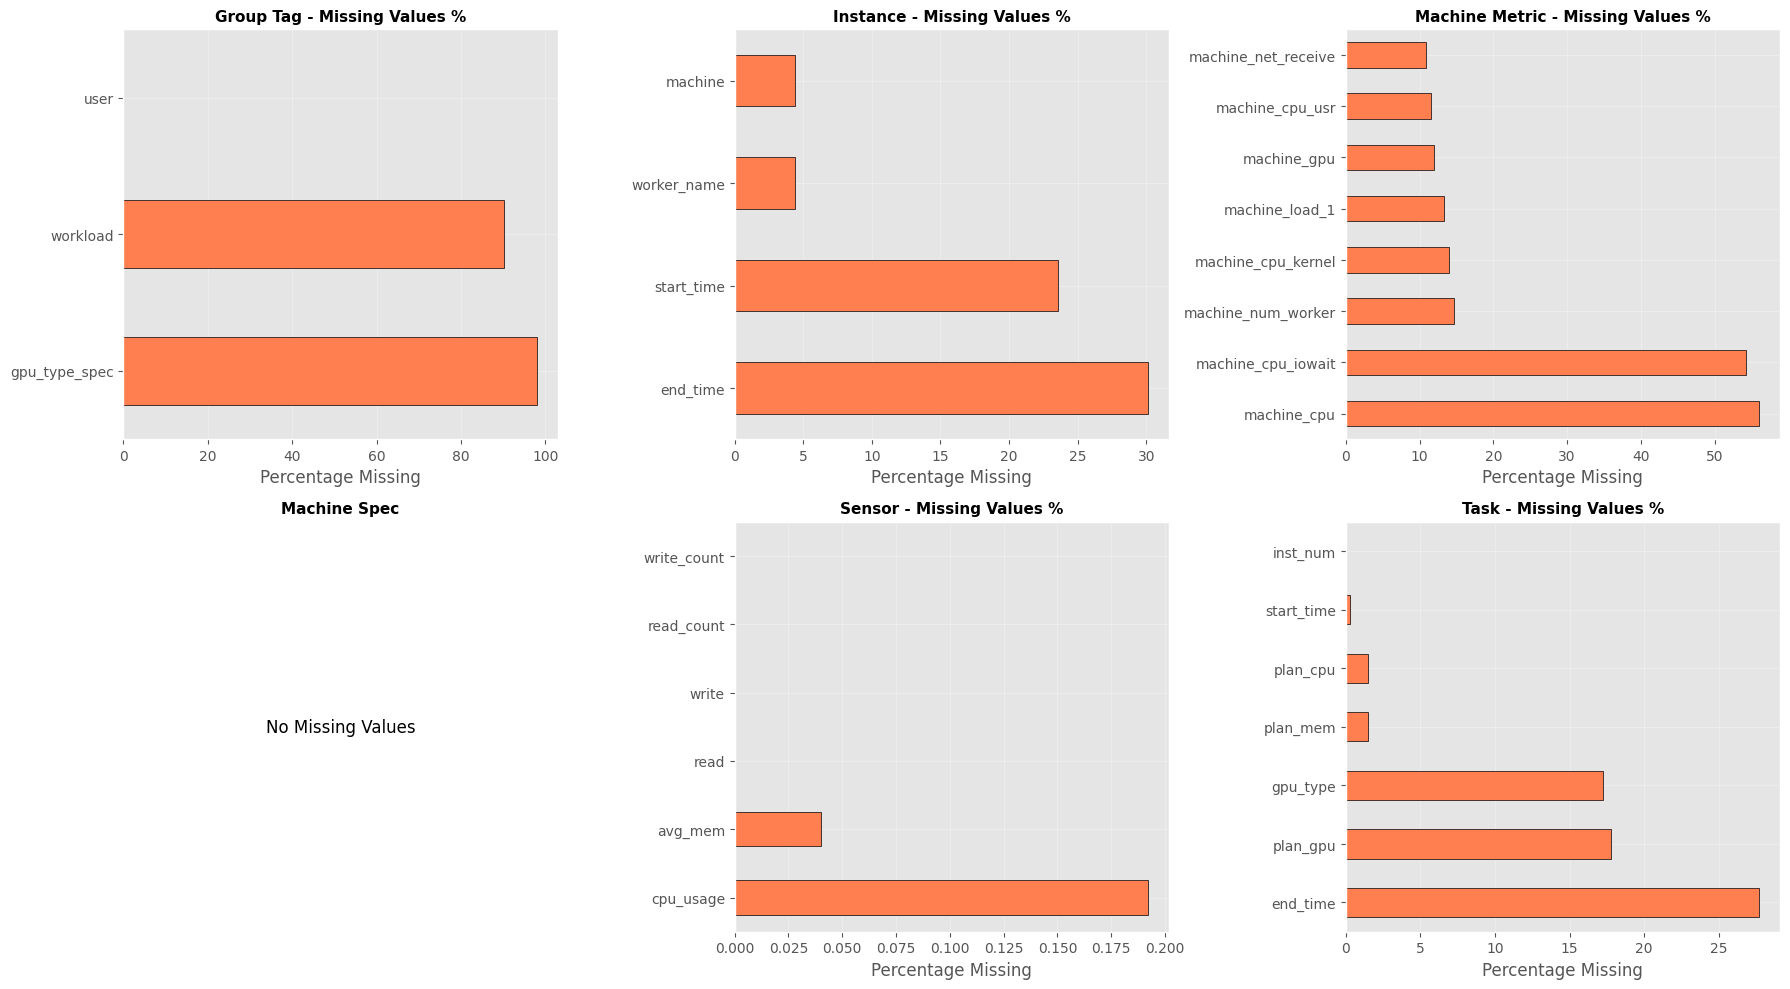

In [54]:
# Visualize missing values
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, df) in enumerate(datasets.items()):
    if idx < 6:
        missing_pct = (df.isnull().sum() / len(df)) * 100
        missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
        
        if len(missing_pct) > 0:
            missing_pct.head(10).plot(kind='barh', ax=axes[idx], color='coral', edgecolor='black')
            axes[idx].set_title(f'{name} - Missing Values %', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel('Percentage Missing')
            axes[idx].grid(True, alpha=0.3)
        else:
            axes[idx].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=12)
            axes[idx].set_title(f'{name}', fontsize=11, fontweight='bold')
            axes[idx].axis('off')

plt.tight_layout()
plt.show()

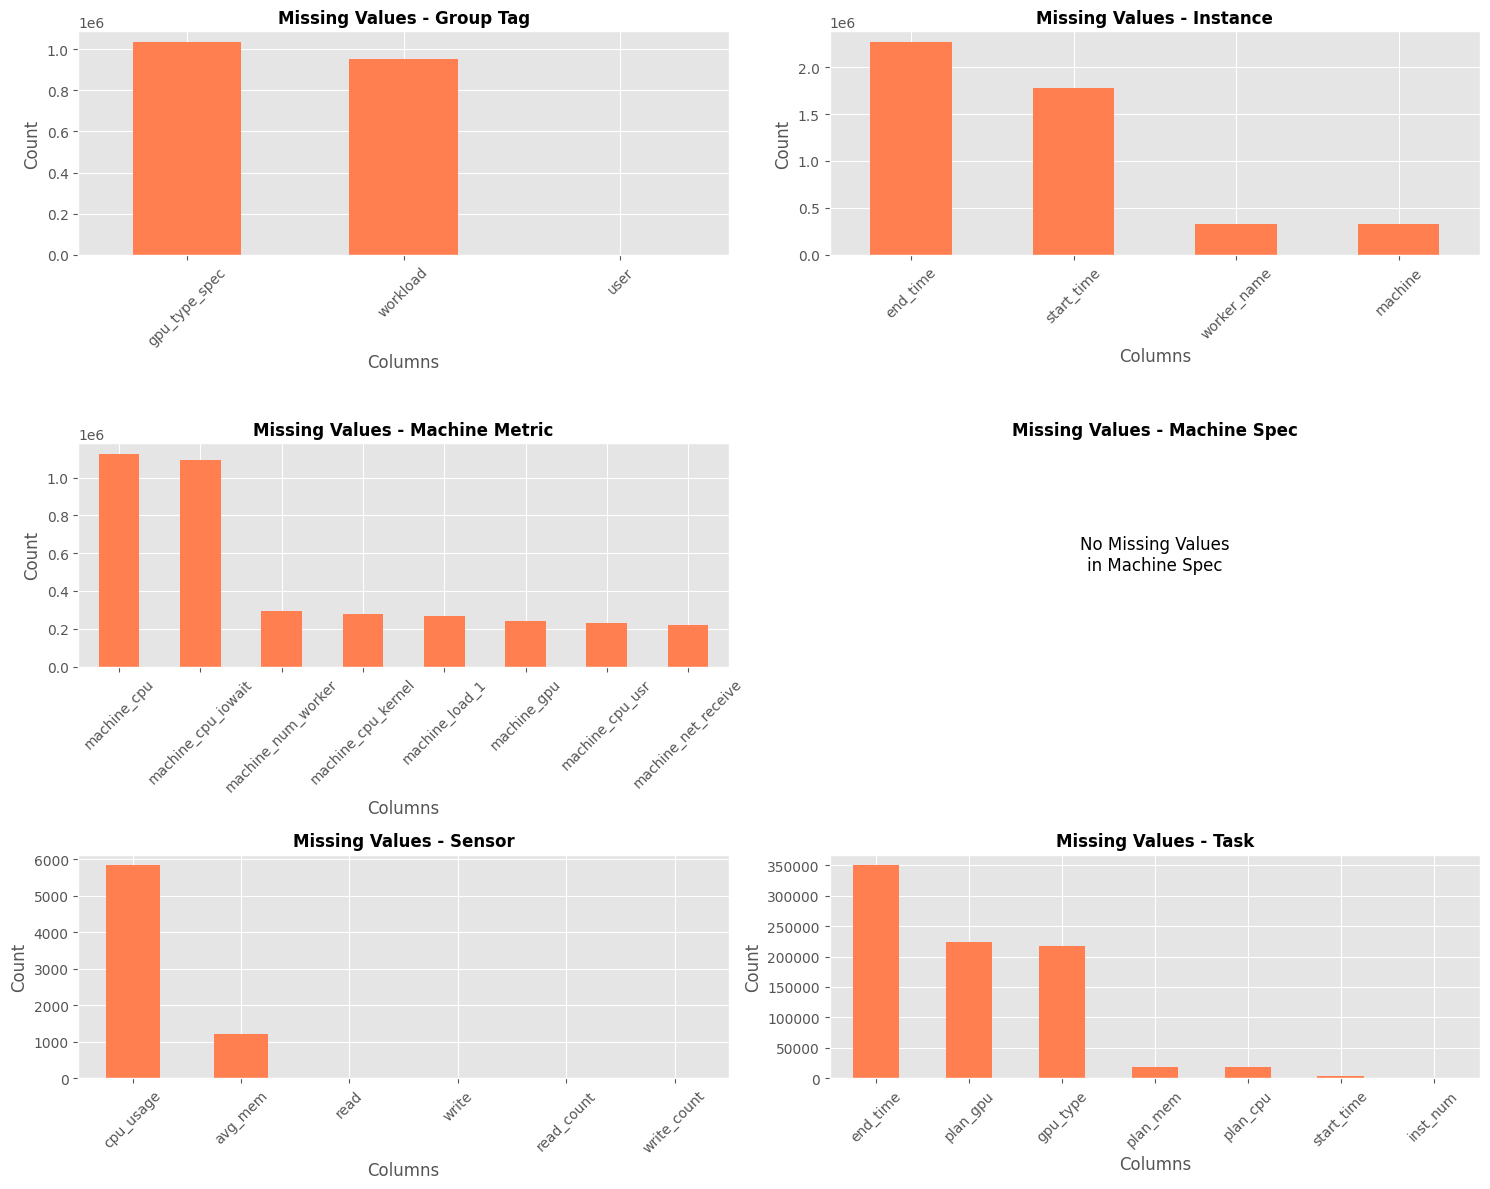

In [55]:
# Visualize missing values
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (name, df) in enumerate(datasets.items()):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) > 0:
        missing.plot(kind='bar', ax=axes[idx], color='coral')
        axes[idx].set_title(f'Missing Values - {name}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Count')
        axes[idx].set_xlabel('Columns')
        axes[idx].tick_params(axis='x', rotation=45)
    else:
        axes[idx].text(0.5, 0.5, f'No Missing Values\nin {name}', 
                      ha='center', va='center', fontsize=12)
        axes[idx].set_title(f'Missing Values - {name}', fontsize=12, fontweight='bold')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 6. Data Distribution Visualization

Visualize the distribution of key numerical features.

### 6.1 Task Table - Resource Requests Distribution

In [ ]:
# Distribution of resource requests in tasks
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# CPU requests
axes[0, 0].hist(task['plan_cpu'].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of CPU Requests (plan_cpu)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('CPU Cores (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_xlim(0, task['plan_cpu'].quantile(0.95))

# Memory requests
axes[0, 1].hist(task['plan_mem'].dropna(), bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution of Memory Requests (plan_mem)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Memory (GB)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xlim(0, task['plan_mem'].quantile(0.95))

# GPU requests
axes[1, 0].hist(task['plan_gpu'].dropna(), bins=50, color='salmon', edgecolor='black')
axes[1, 0].set_title('Distribution of GPU Requests (plan_gpu)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('GPU (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_xlim(0, task['plan_gpu'].quantile(0.95))

# Instance count
axes[1, 1].hist(task['inst_num'].dropna(), bins=50, color='gold', edgecolor='black')
axes[1, 1].set_title('Distribution of Instance Numbers', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Instances')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xlim(0, task['inst_num'].quantile(0.95))

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (3953951562.py, line 31)

### 6.2 Sensor Table - Resource Usage Distribution

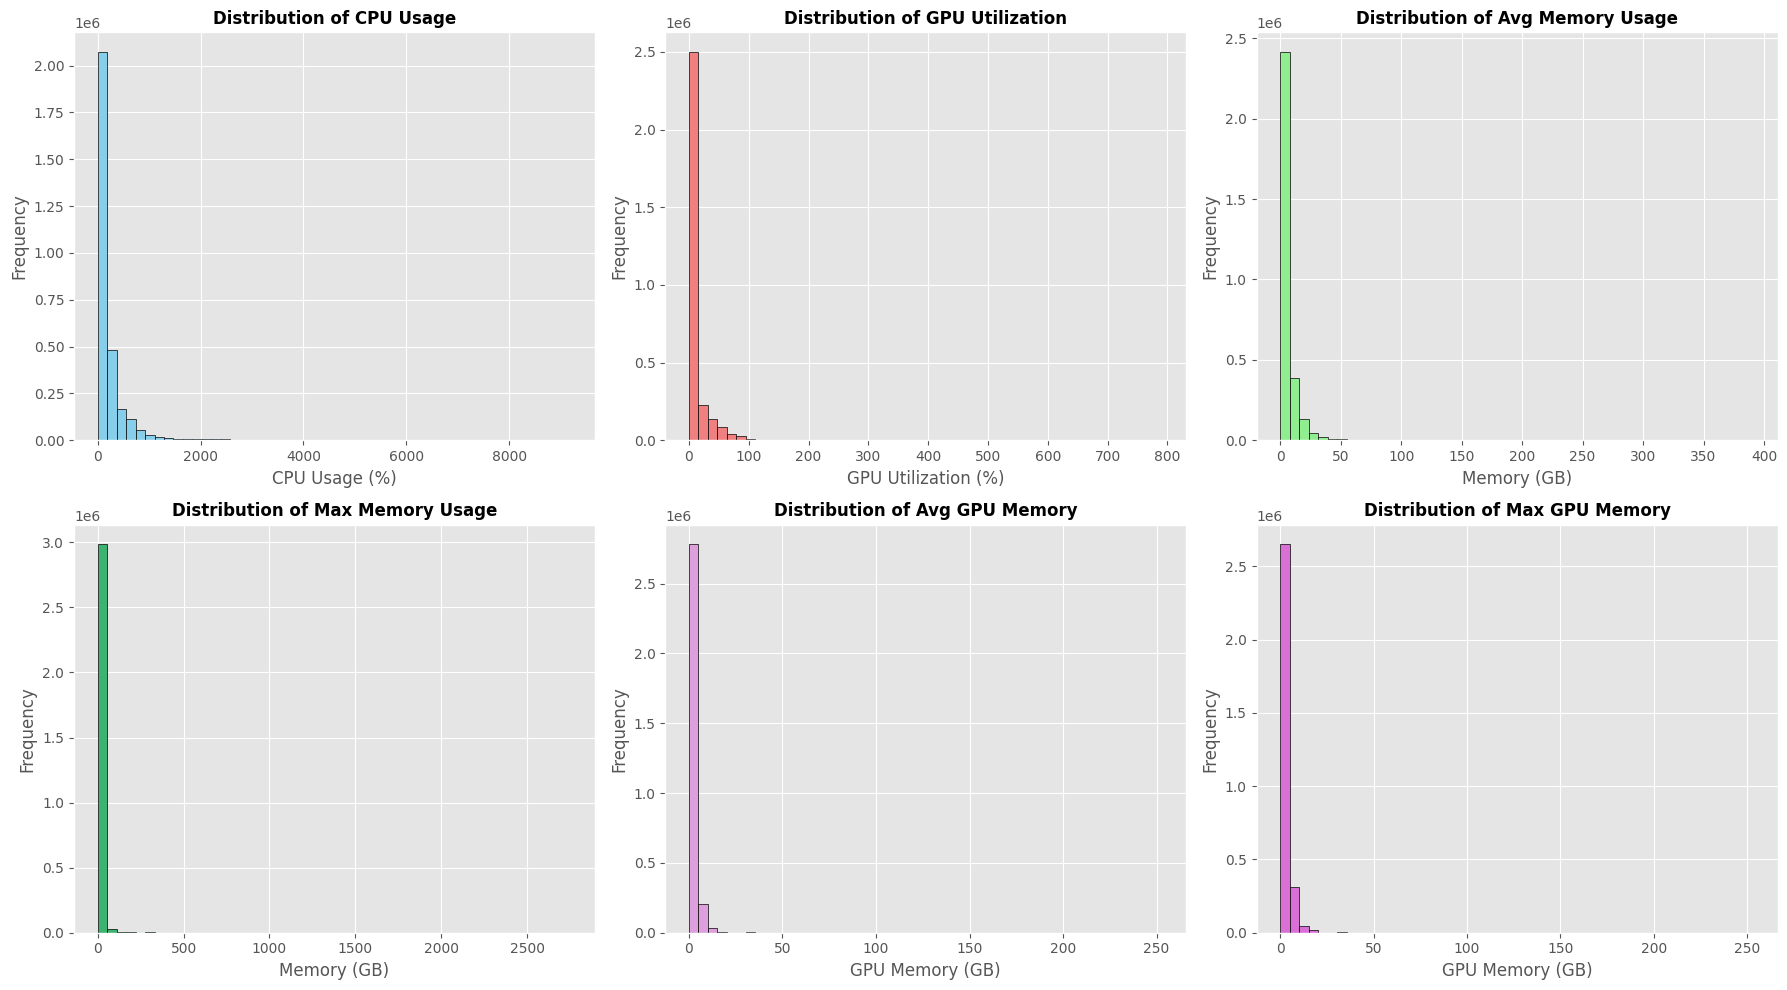

In [ ]:
# Distribution of actual resource usage from sensors
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# CPU usage
axes[0, 0].hist(sensor['cpu_usage'].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of CPU Usage', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('CPU Usage (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_xlim(0, sensor['cpu_usage'].quantile(0.95))

# GPU usage
axes[0, 1].hist(sensor['gpu_wrk_util'].dropna(), bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Distribution of GPU Utilization', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('GPU Utilization (%)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xlim(0, sensor['gpu_wrk_util'].quantile(0.95))

# Average memory
axes[0, 2].hist(sensor['avg_mem'].dropna(), bins=50, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Distribution of Avg Memory Usage', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Memory (GB)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_xlim(0, sensor['avg_mem'].quantile(0.95))

# Max memory
axes[1, 0].hist(sensor['max_mem'].dropna(), bins=50, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Distribution of Max Memory Usage', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Memory (GB)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_xlim(0, sensor['max_mem'].quantile(0.95))

# Average GPU memory
axes[1, 1].hist(sensor['avg_gpu_wrk_mem'].dropna(), bins=50, color='plum', edgecolor='black')
axes[1, 1].set_title('Distribution of Avg GPU Memory', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('GPU Memory (GB)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xlim(0, sensor['avg_gpu_wrk_mem'].quantile(0.95))

# Max GPU memory
axes[1, 2].hist(sensor['max_gpu_wrk_mem'].dropna(), bins=50, color='orchid', edgecolor='black')
axes[1, 2].set_title('Distribution of Max GPU Memory', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('GPU Memory (GB)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_xlim(0, sensor['max_gpu_wrk_mem'].quantile(0.95))

plt.tight_layout()
plt.show()

## 7. Memory Requested vs Used Analysis

This is the key analysis for resource optimization. We'll compare:
- **plan_mem** (requested memory from task table)
- **avg_mem** and **max_mem** (actual memory used from sensor table)

To join these datasets, we need to link them through job_name and worker_name.

### 7.1 Join Task and Sensor Data

In [ ]:
# Merge task and sensor tables to compare requested vs used resources
# Join on job_name and task_name
memory_analysis = task[['job_name', 'task_name', 'plan_cpu', 'plan_mem', 'plan_gpu']].merge(
    sensor[['job_name', 'task_name', 'worker_name', 'cpu_usage', 'avg_mem', 'max_mem', 
            'gpu_wrk_util', 'avg_gpu_wrk_mem', 'max_gpu_wrk_mem']],
    on=['job_name', 'task_name'],
    how='inner'
)

print(f"Merged dataset shape: {memory_analysis.shape}")
print(f"\nFirst 5 rows of merged data:")
display(memory_analysis.head())

print(f"\nMerged data info:")
memory_analysis.info()

Merged dataset shape: (3023697, 12)

First 5 rows of merged data:


,job_name,task_name,plan_cpu,plan_mem,plan_gpu,worker_name,cpu_usage,avg_mem,max_mem,gpu_wrk_util,avg_gpu_wrk_mem,max_gpu_wrk_mem
0,c936346f45eccd34bf748541,tensorflow,600.0,29.296875,50.0,48c6a3df1e046ca0fb5331b18c1d23f47312e806a623a4...,350.353167,24.306558,30.613281,77.468451,4.184025,4.354492
1,455c3dec270f4777ad67721c,tensorflow,600.0,29.296875,100.0,60fa808be024e77c81c13a5ae2b336ad35fd837e59cc80...,117.888889,1.870295,2.862305,0.333333,0.069743,0.836914
2,ba64aa2f0feff18428923e92,tensorflow,600.0,29.296875,50.0,6b409158890a93dc245e0860fc9bd18c05e0adb2502fb7...,139.502103,12.811959,13.503906,4.408403,4.212840,4.258789
3,704783be2a4b7f88b8d2e4ee,worker,600.0,9.765625,10.0,8af8d63050be4502eb06a7a03571fcfb9b112c6da3fc05...,90.543478,16.871221,42.729492,9.829787,0.431267,1.084961
4,704783be2a4b7f88b8d2e4ee,worker,600.0,9.765625,10.0,c5fe51a2774fd6629699887f2887059e9f61972958913b...,89.739130,18.169752,74.735352,20.170213,0.433511,1.084961



Merged data info:
<class 'pandas.DataFrame'>
RangeIndex: 3023697 entries, 0 to 3023696
Data columns (total 12 columns):
 #   Column           Dtype  
---  ------           -----  
 0   job_name         str    
 1   task_name        str    
 2   plan_cpu         float64
 3   plan_mem         float64
 4   plan_gpu         float64
 5   worker_name      str    
 6   cpu_usage        float64
 7   avg_mem          float64
 8   max_mem          float64
 9   gpu_wrk_util     float64
 10  avg_gpu_wrk_mem  float64
 11  max_gpu_wrk_mem  float64
dtypes: float64(9), str(3)
memory usage: 276.8 MB


### 7.2 Calculate Memory Utilization Metrics

In [ ]:
# Calculate utilization ratios
memory_analysis['mem_avg_utilization'] = (memory_analysis['avg_mem'] / memory_analysis['plan_mem']) * 100
memory_analysis['mem_max_utilization'] = (memory_analysis['max_mem'] / memory_analysis['plan_mem']) * 100
memory_analysis['mem_waste_avg'] = memory_analysis['plan_mem'] - memory_analysis['avg_mem']
memory_analysis['mem_waste_max'] = memory_analysis['plan_mem'] - memory_analysis['max_mem']

# CPU utilization
memory_analysis['cpu_utilization'] = (memory_analysis['cpu_usage'] / memory_analysis['plan_cpu']) * 100

# GPU utilization
memory_analysis['gpu_utilization'] = (memory_analysis['gpu_wrk_util'] / memory_analysis['plan_gpu']) * 100

print("Memory Utilization Statistics (based on Average Memory):")
print("=" * 70)
print(f"Mean Utilization: {memory_analysis['mem_avg_utilization'].mean():.2f}%")
print(f"Median Utilization: {memory_analysis['mem_avg_utilization'].median():.2f}%")
print(f"Std Dev: {memory_analysis['mem_avg_utilization'].std():.2f}%")
print(f"Min Utilization: {memory_analysis['mem_avg_utilization'].min():.2f}%")
print(f"Max Utilization: {memory_analysis['mem_avg_utilization'].max():.2f}%")

print("\n\nMemory Utilization Statistics (based on Max Memory):")
print("=" * 70)
print(f"Mean Utilization: {memory_analysis['mem_max_utilization'].mean():.2f}%")
print(f"Median Utilization: {memory_analysis['mem_max_utilization'].median():.2f}%")
print(f"Std Dev: {memory_analysis['mem_max_utilization'].std():.2f}%")
print(f"Min Utilization: {memory_analysis['mem_max_utilization'].min():.2f}%")
print(f"Max Utilization: {memory_analysis['mem_max_utilization'].max():.2f}%")

print("\n\nMemory Waste Statistics (Average):")
print("=" * 70)
print(f"Total Memory Requested: {memory_analysis['plan_mem'].sum():.2f} GB")
print(f"Total Memory Used (Avg): {memory_analysis['avg_mem'].sum():.2f} GB")
print(f"Total Memory Wasted (Avg): {memory_analysis['mem_waste_avg'].sum():.2f} GB")
print(f"Average Waste per Instance: {memory_analysis['mem_waste_avg'].mean():.2f} GB")
print(f"Waste Percentage: {(memory_analysis['mem_waste_avg'].sum() / memory_analysis['plan_mem'].sum()) * 100:.2f}%")

Memory Utilization Statistics (based on Average Memory):
Mean Utilization: 29.19%
Median Utilization: 11.80%
Std Dev: 44.81%
Min Utilization: 0.00%
Max Utilization: 969.96%


Memory Utilization Statistics (based on Max Memory):
Mean Utilization: 46.45%
Median Utilization: 19.61%
Std Dev: 86.74%
Min Utilization: 0.00%
Max Utilization: 8000.00%


Memory Waste Statistics (Average):
Total Memory Requested: 81867682.11 GB
Total Memory Used (Avg): 16717734.90 GB
Total Memory Wasted (Avg): 65114836.17 GB
Average Waste per Instance: 21.55 GB
Waste Percentage: 79.54%


### 7.3 Visualize Memory Requested vs Used

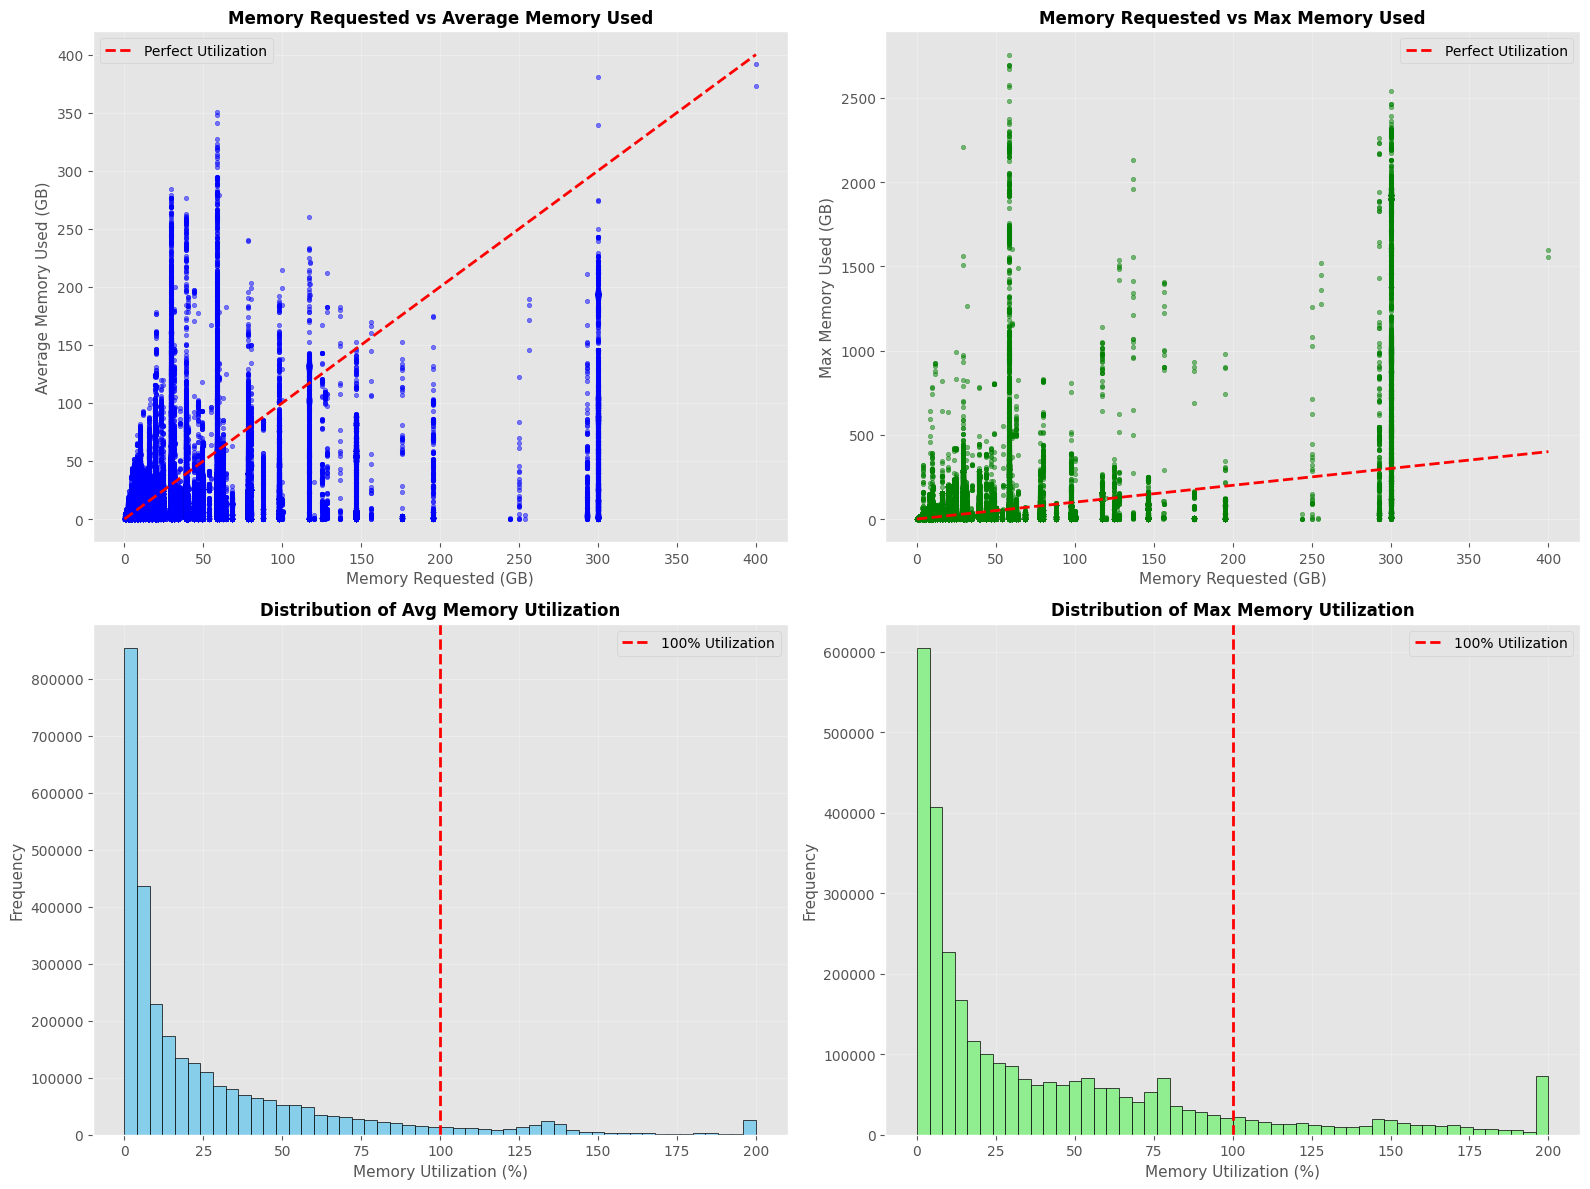

In [ ]:
# Scatter plot: Requested vs Used Memory
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Plan Memory vs Average Memory Used
axes[0, 0].scatter(memory_analysis['plan_mem'], memory_analysis['avg_mem'], 
                   alpha=0.5, s=10, color='blue')
axes[0, 0].plot([0, memory_analysis['plan_mem'].max()], 
                [0, memory_analysis['plan_mem'].max()], 
                'r--', label='Perfect Utilization', linewidth=2)
axes[0, 0].set_xlabel('Memory Requested (GB)', fontsize=11)
axes[0, 0].set_ylabel('Average Memory Used (GB)', fontsize=11)
axes[0, 0].set_title('Memory Requested vs Average Memory Used', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Plan Memory vs Max Memory Used
axes[0, 1].scatter(memory_analysis['plan_mem'], memory_analysis['max_mem'], 
                   alpha=0.5, s=10, color='green')
axes[0, 1].plot([0, memory_analysis['plan_mem'].max()], 
                [0, memory_analysis['plan_mem'].max()], 
                'r--', label='Perfect Utilization', linewidth=2)
axes[0, 1].set_xlabel('Memory Requested (GB)', fontsize=11)
axes[0, 1].set_ylabel('Max Memory Used (GB)', fontsize=11)
axes[0, 1].set_title('Memory Requested vs Max Memory Used', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Memory Utilization Distribution (Average)
axes[1, 0].hist(memory_analysis['mem_avg_utilization'].dropna().clip(0, 200), 
                bins=50, color='skyblue', edgecolor='black')
axes[1, 0].axvline(100, color='red', linestyle='--', linewidth=2, label='100% Utilization')
axes[1, 0].set_xlabel('Memory Utilization (%)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Distribution of Avg Memory Utilization', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Memory Utilization Distribution (Max)
axes[1, 1].hist(memory_analysis['mem_max_utilization'].dropna().clip(0, 200), 
                bins=50, color='lightgreen', edgecolor='black')
axes[1, 1].axvline(100, color='red', linestyle='--', linewidth=2, label='100% Utilization')
axes[1, 1].set_xlabel('Memory Utilization (%)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Distribution of Max Memory Utilization', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

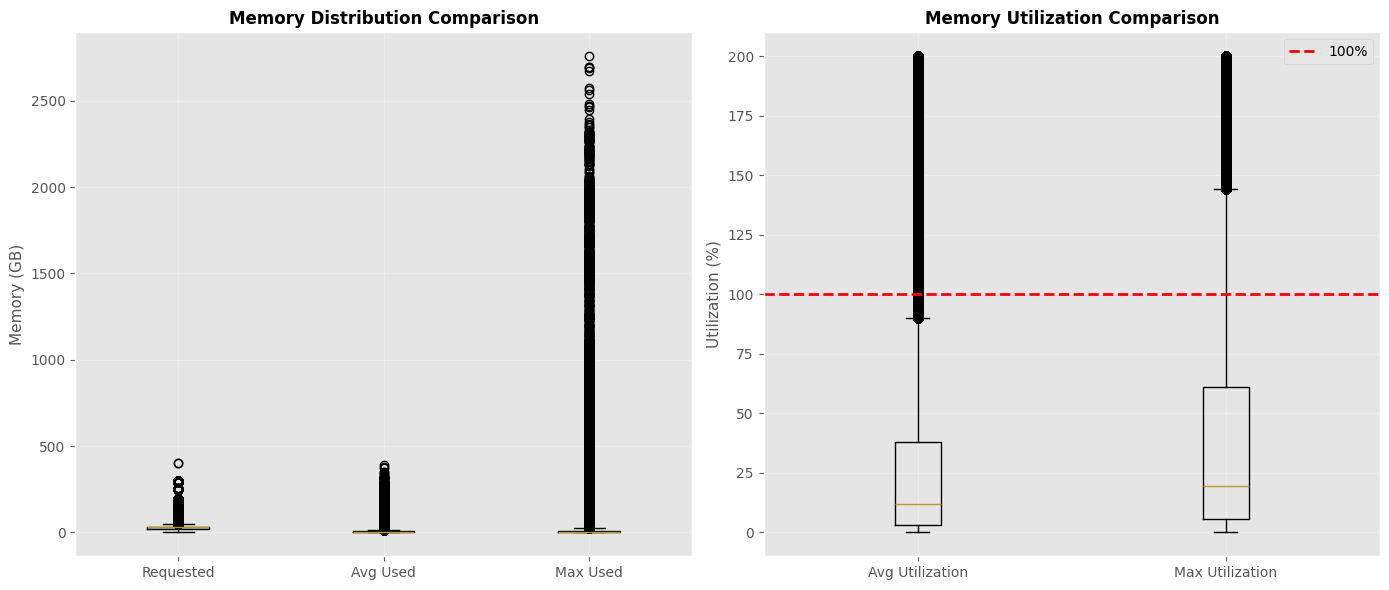

In [ ]:
# Box plots for memory comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot comparison
data_to_plot = [memory_analysis['plan_mem'].dropna(), 
                memory_analysis['avg_mem'].dropna(), 
                memory_analysis['max_mem'].dropna()]
axes[0].boxplot(data_to_plot, labels=['Requested', 'Avg Used', 'Max Used'])
axes[0].set_ylabel('Memory (GB)', fontsize=11)
axes[0].set_title('Memory Distribution Comparison', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Utilization box plot
data_util = [memory_analysis['mem_avg_utilization'].dropna().clip(0, 200),
             memory_analysis['mem_max_utilization'].dropna().clip(0, 200)]
axes[1].boxplot(data_util, labels=['Avg Utilization', 'Max Utilization'])
axes[1].axhline(100, color='red', linestyle='--', linewidth=2, label='100%')
axes[1].set_ylabel('Utilization (%)', fontsize=11)
axes[1].set_title('Memory Utilization Comparison', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.4 Over-provisioning and Under-provisioning Analysis

Provisioning Categories:
provisioning_category
Severely Over-provisioned (< 50%)        2087685
Over-provisioned (50-75%)                 349763
Under-provisioned (> 125%)                262803
Well-provisioned (75-100%)                222111
Slightly Under-provisioned (100-125%)     101335
Name: count, dtype: int64

Total instances: 3023697


Percentage Breakdown:
Severely Over-provisioned (< 50%): 69.04%
Over-provisioned (50-75%): 11.57%
Under-provisioned (> 125%): 8.69%
Well-provisioned (75-100%): 7.35%
Slightly Under-provisioned (100-125%): 3.35%


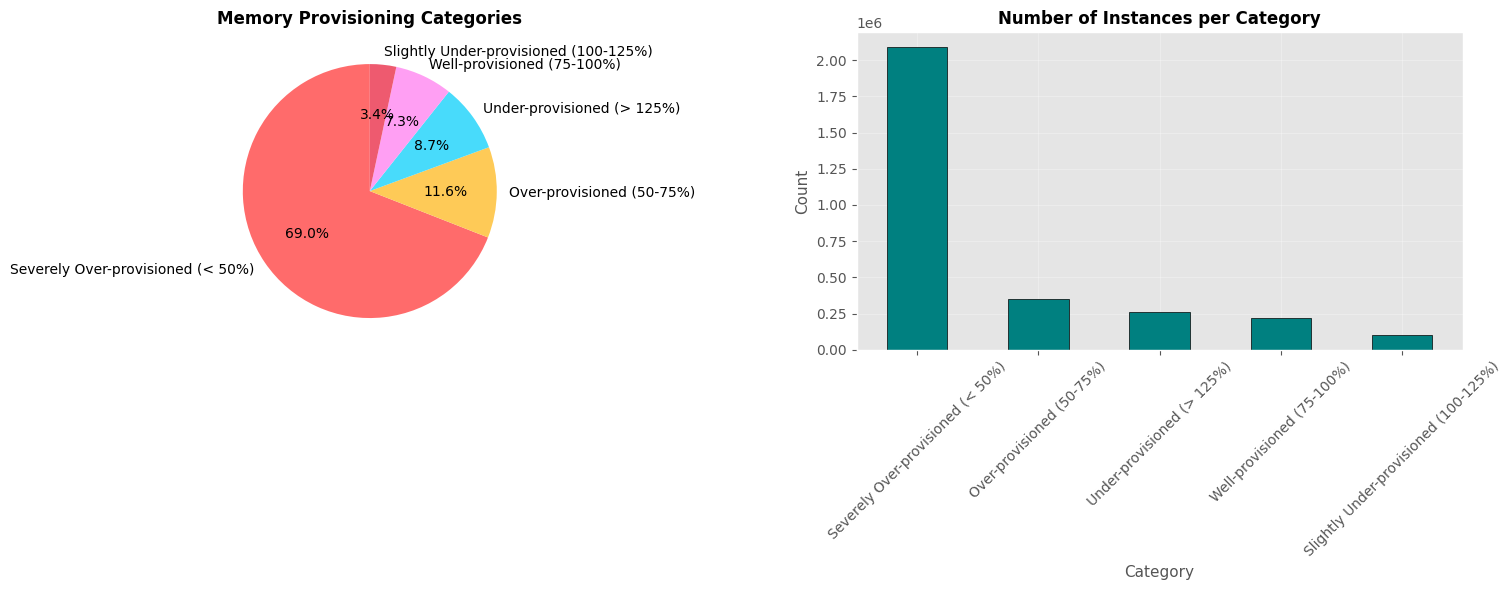

In [ ]:
# Categorize instances based on max memory utilization
def categorize_provisioning(util):
    if util < 50:
        return 'Severely Over-provisioned (< 50%)'
    elif util < 75:
        return 'Over-provisioned (50-75%)'
    elif util < 100:
        return 'Well-provisioned (75-100%)'
    elif util < 125:
        return 'Slightly Under-provisioned (100-125%)'
    else:
        return 'Under-provisioned (> 125%)'

memory_analysis['provisioning_category'] = memory_analysis['mem_max_utilization'].apply(categorize_provisioning)

# Count instances in each category
category_counts = memory_analysis['provisioning_category'].value_counts()
print("Provisioning Categories:")
print("=" * 70)
print(category_counts)
print(f"\nTotal instances: {len(memory_analysis)}")

# Percentage breakdown
print("\n\nPercentage Breakdown:")
print("=" * 70)
for cat, count in category_counts.items():
    pct = (count / len(memory_analysis)) * 100
    print(f"{cat}: {pct:.2f}%")

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart for categories
colors = ['#ff6b6b', '#feca57', '#48dbfb', '#ff9ff3', '#ee5a6f']
axes[0].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
           colors=colors, startangle=90)
axes[0].set_title('Memory Provisioning Categories', fontsize=12, fontweight='bold')

# Bar chart
category_counts.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Number of Instances per Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Category', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.5 CPU and GPU Utilization Analysis

CPU Utilization Statistics:
Mean: 96.22%
Median: 23.12%
Std Dev: 771.39%


GPU Utilization Statistics:
Mean: 17.91%
Median: 3.67%
Std Dev: 36.04%


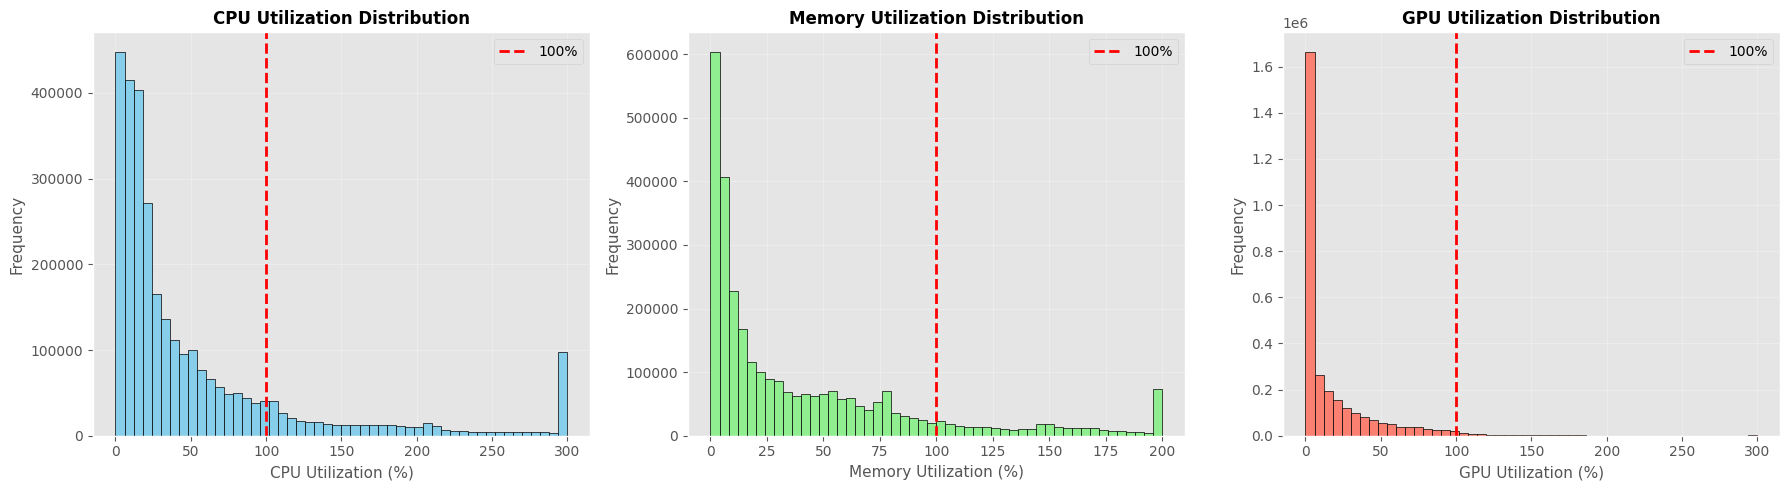

In [ ]:
# CPU and GPU utilization statistics
print("CPU Utilization Statistics:")
print("=" * 70)
print(f"Mean: {memory_analysis['cpu_utilization'].mean():.2f}%")
print(f"Median: {memory_analysis['cpu_utilization'].median():.2f}%")
print(f"Std Dev: {memory_analysis['cpu_utilization'].std():.2f}%")

print("\n\nGPU Utilization Statistics:")
print("=" * 70)
gpu_stats = memory_analysis['gpu_utilization'].dropna()
if len(gpu_stats) > 0:
    print(f"Mean: {gpu_stats.mean():.2f}%")
    print(f"Median: {gpu_stats.median():.2f}%")
    print(f"Std Dev: {gpu_stats.std():.2f}%")
else:
    print("No GPU utilization data available")

# Visualize all resource utilization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CPU
axes[0].hist(memory_analysis['cpu_utilization'].dropna().clip(0, 300), 
             bins=50, color='skyblue', edgecolor='black')
axes[0].axvline(100, color='red', linestyle='--', linewidth=2, label='100%')
axes[0].set_xlabel('CPU Utilization (%)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('CPU Utilization Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Memory (max)
axes[1].hist(memory_analysis['mem_max_utilization'].dropna().clip(0, 200), 
             bins=50, color='lightgreen', edgecolor='black')
axes[1].axvline(100, color='red', linestyle='--', linewidth=2, label='100%')
axes[1].set_xlabel('Memory Utilization (%)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Memory Utilization Distribution', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# GPU
gpu_util_data = memory_analysis['gpu_utilization'].dropna().clip(0, 300)
if len(gpu_util_data) > 0:
    axes[2].hist(gpu_util_data, bins=50, color='salmon', edgecolor='black')
    axes[2].axvline(100, color='red', linestyle='--', linewidth=2, label='100%')
    axes[2].set_xlabel('GPU Utilization (%)', fontsize=11)
    axes[2].set_ylabel('Frequency', fontsize=11)
    axes[2].set_title('GPU Utilization Distribution', fontsize=12, fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'No GPU Data', ha='center', va='center', fontsize=14)
    axes[2].set_title('GPU Utilization Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

Examine relationships between different resource metrics.

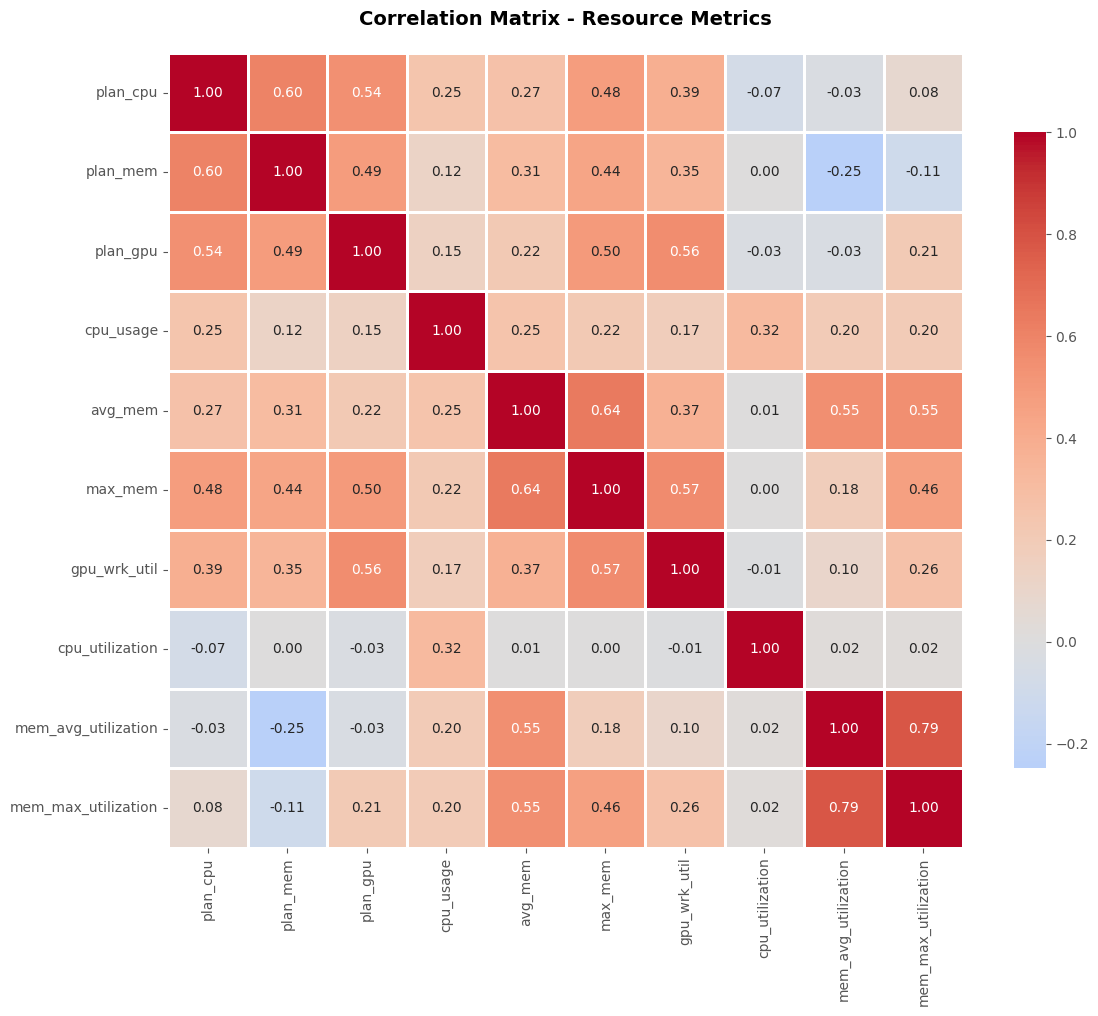


Key Correlations:

Top 10 Positive Correlations:
mem_max_utilization  mem_avg_utilization    0.785433
max_mem              avg_mem                0.640444
plan_mem             plan_cpu               0.603552
gpu_wrk_util         max_mem                0.568734
                     plan_gpu               0.556460
mem_max_utilization  avg_mem                0.552981
mem_avg_utilization  avg_mem                0.547403
plan_gpu             plan_cpu               0.544064
max_mem              plan_gpu               0.496911
plan_gpu             plan_mem               0.491334
dtype: float64


Top 10 Negative Correlations:
gpu_wrk_util         gpu_wrk_util          NaN
                     cpu_utilization       NaN
                     mem_avg_utilization   NaN
                     mem_max_utilization   NaN
cpu_utilization      cpu_utilization       NaN
                     mem_avg_utilization   NaN
                     mem_max_utilization   NaN
mem_avg_utilization  mem_avg_utilization   N

In [ ]:
# Correlation matrix for resource metrics
corr_columns = ['plan_cpu', 'plan_mem', 'plan_gpu', 'cpu_usage', 'avg_mem', 'max_mem',
                'gpu_wrk_util', 'cpu_utilization', 'mem_avg_utilization', 'mem_max_utilization']

# Select only numeric columns that exist
corr_data = memory_analysis[corr_columns].select_dtypes(include=[np.number])
correlation_matrix = corr_data.corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Resource Metrics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Key correlations
print("\nKey Correlations:")
print("=" * 70)
print("\nTop 10 Positive Correlations:")
# Get upper triangle of correlation matrix
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlations = upper_tri.unstack().sort_values(ascending=False)
print(correlations.head(10))

print("\n\nTop 10 Negative Correlations:")
print(correlations.tail(10))

## 9. Feature Analysis

Analyze specific features and patterns in the data.

### 9.1 GPU Type Distribution

GPU Type Distribution in Tasks:
gpu_type
MISC       696281
T4         226923
P100        72732
V100        28797
V100M32     18579
Name: count, dtype: int64

Total tasks: 1261050
Tasks with GPU: 1043312


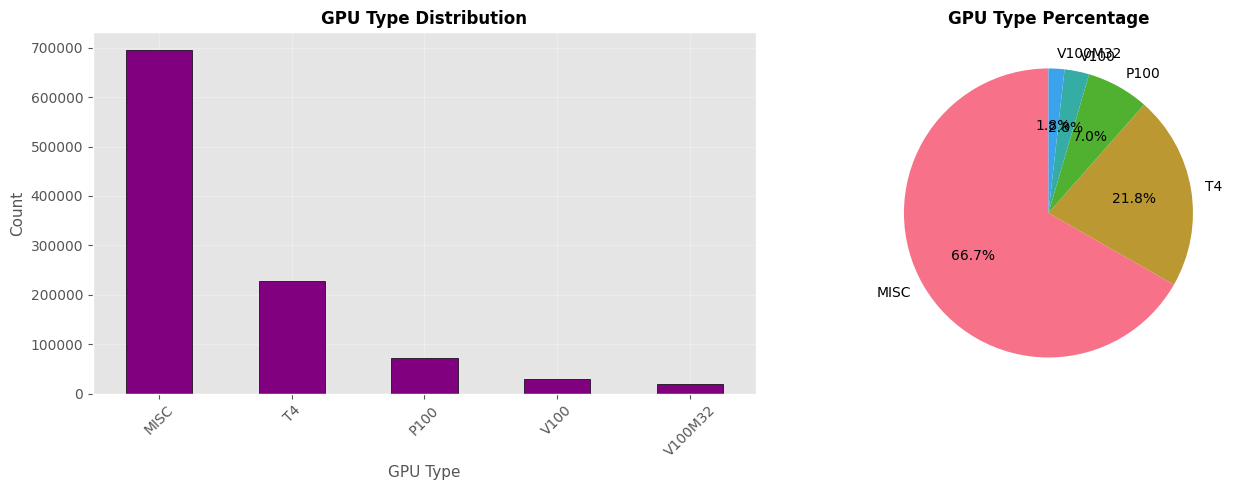



GPU Type Distribution in Machines:
gpu_type
P100       798
T4         497
MISC       280
V100M32    135
V100       104
CPU         83
Name: count, dtype: int64


In [ ]:
# GPU type distribution from task table
print("GPU Type Distribution in Tasks:")
print("=" * 70)
gpu_type_counts = task['gpu_type'].value_counts()
print(gpu_type_counts)
print(f"\nTotal tasks: {len(task)}")
print(f"Tasks with GPU: {task['gpu_type'].notna().sum()}")

# Visualize GPU types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
gpu_type_counts.plot(kind='bar', ax=axes[0], color='purple', edgecolor='black')
axes[0].set_title('GPU Type Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('GPU Type', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Pie chart
axes[1].pie(gpu_type_counts.values, labels=gpu_type_counts.index, autopct='%1.1f%%',
           startangle=90)
axes[1].set_title('GPU Type Percentage', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# GPU type from machine spec
print("\n\nGPU Type Distribution in Machines:")
print("=" * 70)
machine_gpu_counts = machine_spec['gpu_type'].value_counts()
print(machine_gpu_counts)

### 9.2 Machine Specifications Analysis

Machine Specifications Summary:

Total unique machines: 1897

CPU Capacity Statistics:
count    1897.000000
mean       82.538745
std        15.801468
min        64.000000
25%        64.000000
50%        96.000000
75%        96.000000
max        96.000000
Name: cap_cpu, dtype: float64

Memory Capacity Statistics:
count    1897.000000
mean      499.854507
std        37.521357
min       384.000000
25%       512.000000
50%       512.000000
75%       512.000000
max       512.000000
Name: cap_mem, dtype: float64

GPU Capacity Statistics:
count    1897.000000
mean        3.554033
std         2.759211
min         0.000000
25%         2.000000
50%         2.000000
75%         8.000000
max         8.000000
Name: cap_gpu, dtype: float64


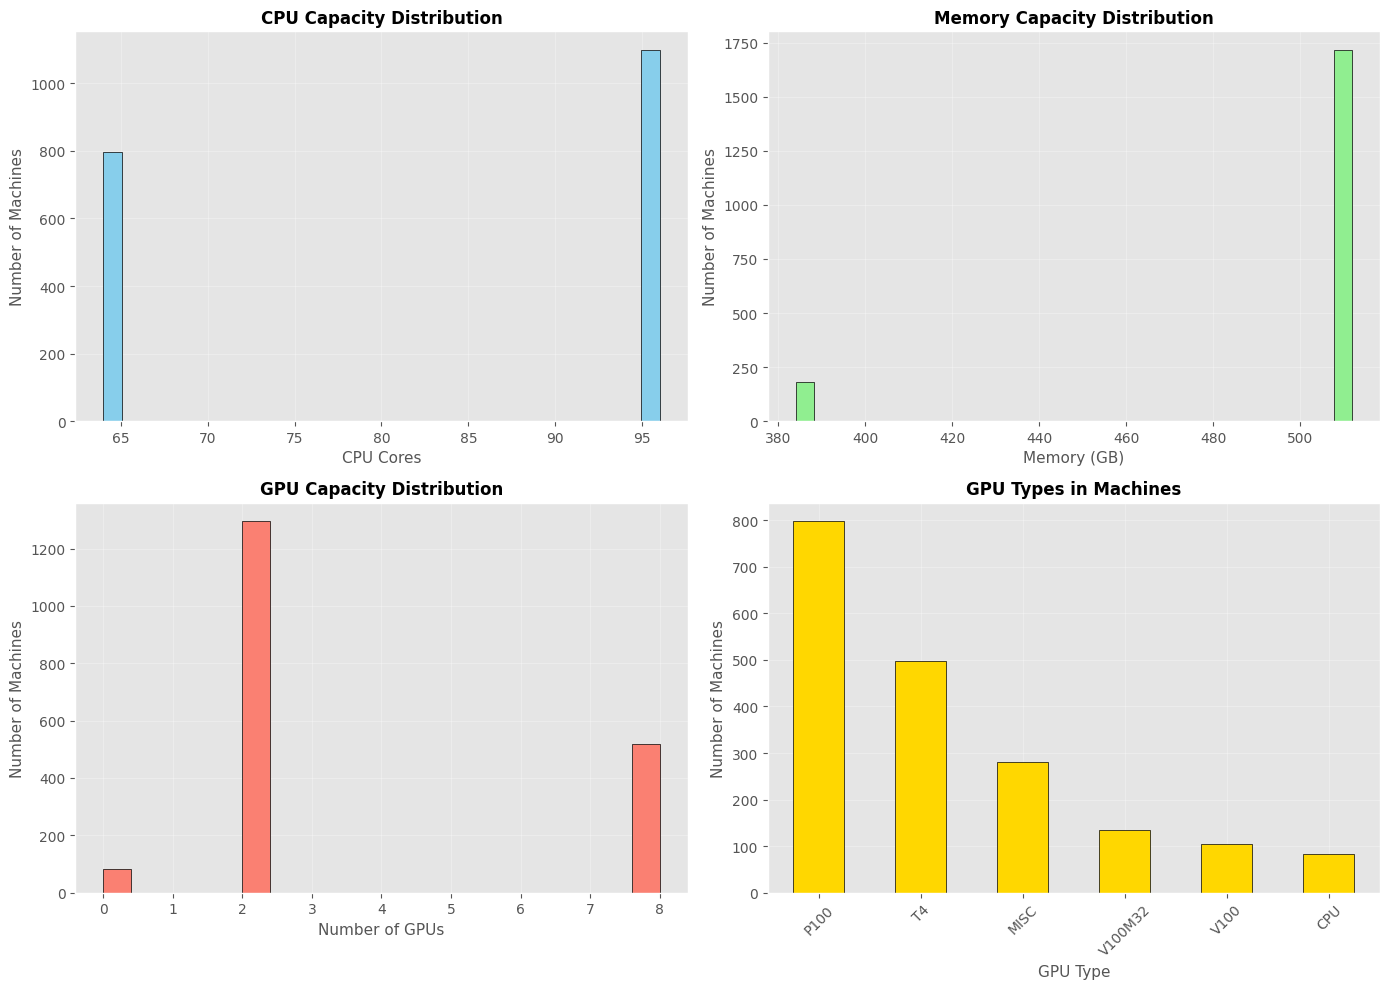

In [ ]:
# Machine specifications summary
print("Machine Specifications Summary:")
print("=" * 70)
print(f"\nTotal unique machines: {machine_spec['machine'].nunique()}")
print(f"\nCPU Capacity Statistics:")
print(machine_spec['cap_cpu'].describe())
print(f"\nMemory Capacity Statistics:")
print(machine_spec['cap_mem'].describe())
print(f"\nGPU Capacity Statistics:")
print(machine_spec['cap_gpu'].describe())

# Visualize machine capabilities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CPU capacity
axes[0, 0].hist(machine_spec['cap_cpu'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('CPU Capacity Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('CPU Cores', fontsize=11)
axes[0, 0].set_ylabel('Number of Machines', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Memory capacity
axes[0, 1].hist(machine_spec['cap_mem'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Memory Capacity Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Memory (GB)', fontsize=11)
axes[0, 1].set_ylabel('Number of Machines', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# GPU capacity
axes[1, 0].hist(machine_spec['cap_gpu'], bins=20, color='salmon', edgecolor='black')
axes[1, 0].set_title('GPU Capacity Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of GPUs', fontsize=11)
axes[1, 0].set_ylabel('Number of Machines', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# GPU types in machines
machine_gpu_counts = machine_spec['gpu_type'].value_counts()
machine_gpu_counts.plot(kind='bar', ax=axes[1, 1], color='gold', edgecolor='black')
axes[1, 1].set_title('GPU Types in Machines', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('GPU Type', fontsize=11)
axes[1, 1].set_ylabel('Number of Machines', fontsize=11)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.3 Task Status Analysis

Task Status Distribution:
status
Terminated    885073
Failed        256762
Running       115501
Waiting         3714
Name: count, dtype: int64

Total tasks: 1261050
Terminated: 70.19%
Failed: 20.36%
Running: 9.16%
Waiting: 0.29%


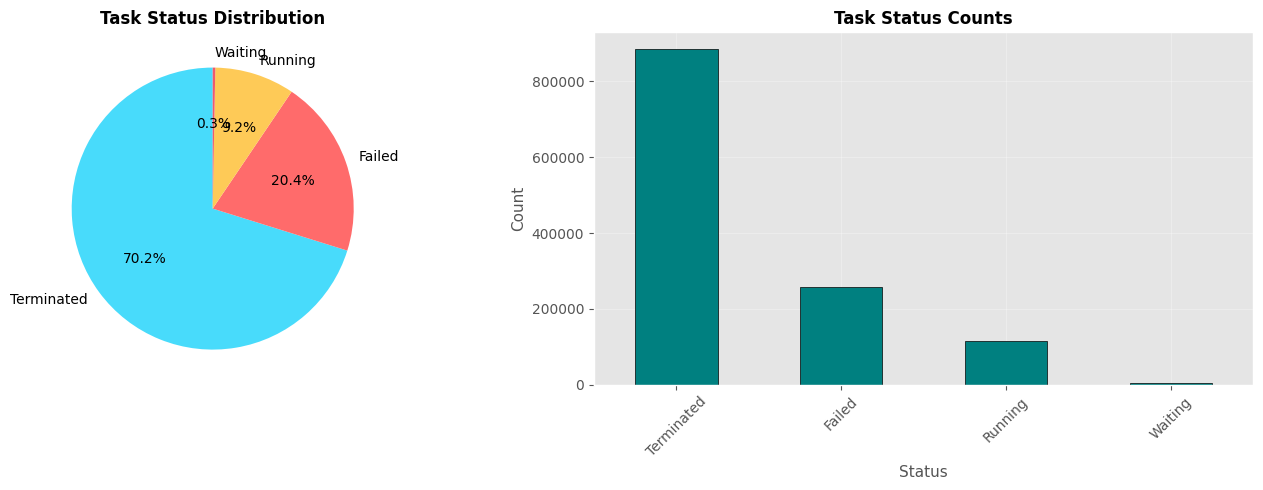



Instance Status Distribution:
status
Terminated     4757371
Failed          969975
Running         809664
Interrupted     654022
Waiting         323840
Ready             7130
Name: count, dtype: int64


In [ ]:
# Task status distribution
print("Task Status Distribution:")
print("=" * 70)
status_counts = task['status'].value_counts()
print(status_counts)
print(f"\nTotal tasks: {len(task)}")

# Calculate percentages
for status, count in status_counts.items():
    pct = (count / len(task)) * 100
    print(f"{status}: {pct:.2f}%")

# Visualize task status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#48dbfb', '#ff6b6b', '#feca57', '#ee5a6f']
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
           colors=colors, startangle=90)
axes[0].set_title('Task Status Distribution', fontsize=12, fontweight='bold')

# Bar chart
status_counts.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Task Status Counts', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Status', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Instance status
print("\n\nInstance Status Distribution:")
print("=" * 70)
inst_status_counts = instance['status'].value_counts()
print(inst_status_counts)

### 9.4 Workload Analysis

Workload Types:
workload
bert          54887
ctr           27083
nmt           10363
inception      5440
graphlearn     3754
resnet          541
xlnet           415
rl              249
vgg              66
Name: count, dtype: int64

Total instances: 1055032
Instances with workload tags: 102798
Percentage tagged: 9.74%


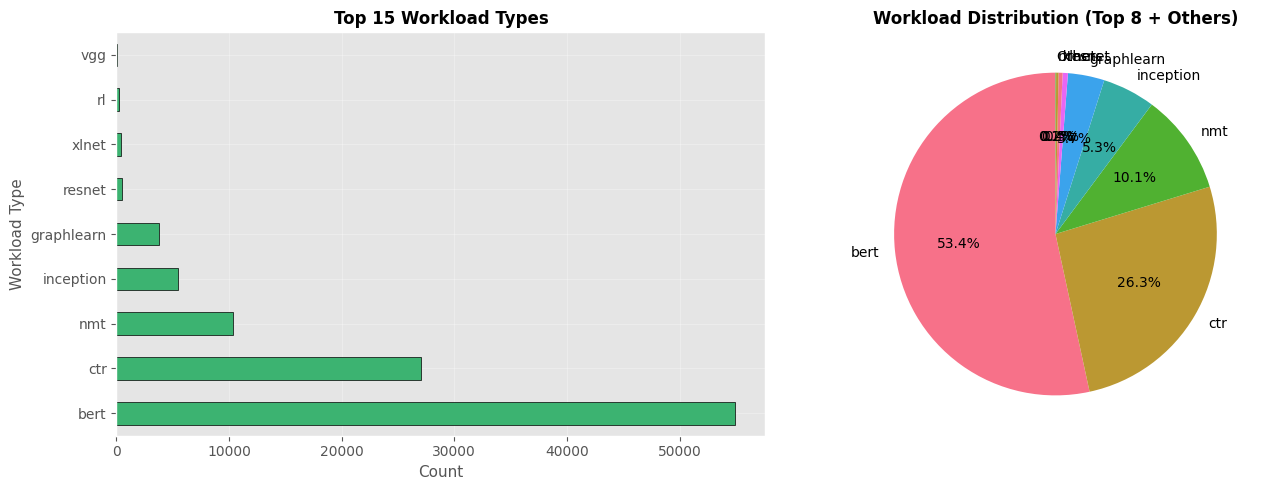



Group Statistics:
Total unique groups: 316956
Average instances per group: 3.33


In [ ]:
# Workload distribution from group_tag table
print("Workload Types:")
print("=" * 70)
workload_counts = group_tag['workload'].value_counts()
print(workload_counts)
print(f"\nTotal instances: {len(group_tag)}")
print(f"Instances with workload tags: {group_tag['workload'].notna().sum()}")
print(f"Percentage tagged: {(group_tag['workload'].notna().sum() / len(group_tag)) * 100:.2f}%")

# Visualize workload distribution
if len(workload_counts) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    workload_counts.head(15).plot(kind='barh', ax=axes[0], color='mediumseagreen', edgecolor='black')
    axes[0].set_title('Top 15 Workload Types', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Count', fontsize=11)
    axes[0].set_ylabel('Workload Type', fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Pie chart for top workloads
    top_workloads = workload_counts.head(8)
    others = workload_counts[8:].sum()
    if others > 0:
        plot_data = pd.concat([top_workloads, pd.Series({'Others': others})])
    else:
        plot_data = top_workloads
    
    axes[1].pie(plot_data.values, labels=plot_data.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Workload Distribution (Top 8 + Others)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No workload data available for visualization")

# Group analysis
print("\n\nGroup Statistics:")
print("=" * 70)
print(f"Total unique groups: {group_tag['group'].nunique()}")
print(f"Average instances per group: {len(group_tag) / group_tag['group'].nunique():.2f}")

## 10. Key Findings and Summary

Summary of the most important insights from the exploratory data analysis.

In [ ]:
# Generate comprehensive summary report
print("=" * 80)
print(" " * 20 + "EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 80)

print("\n📊 DATASET OVERVIEW")
print("-" * 80)
for name, df in datasets.items():
    print(f"  {name:20s}: {df.shape[0]:>10,} rows × {df.shape[1]:>3} columns")

print("\n\n💾 MEMORY UTILIZATION KEY FINDINGS")
print("-" * 80)
if 'memory_analysis' in locals():
    avg_util = memory_analysis['mem_avg_utilization'].mean()
    max_util = memory_analysis['mem_max_utilization'].mean()
    total_requested = memory_analysis['plan_mem'].sum()
    total_used_avg = memory_analysis['avg_mem'].sum()
    total_wasted = memory_analysis['mem_waste_avg'].sum()
    waste_pct = (total_wasted / total_requested) * 100
    
    print(f"  • Average Memory Utilization: {avg_util:.2f}%")
    print(f"  • Average Max Memory Utilization: {max_util:.2f}%")
    print(f"  • Total Memory Requested: {total_requested:,.2f} GB")
    print(f"  • Total Memory Used (Avg): {total_used_avg:,.2f} GB")
    print(f"  • Total Memory Wasted: {total_wasted:,.2f} GB ({waste_pct:.2f}%)")
    print(f"  • Number of analyzed instances: {len(memory_analysis):,}")
    
    print("\n  Provisioning Categories:")
    for cat, count in memory_analysis['provisioning_category'].value_counts().items():
        pct = (count / len(memory_analysis)) * 100
        print(f"    - {cat}: {count:,} ({pct:.1f}%)")

print("\n\n⚙️ RESOURCE UTILIZATION")
print("-" * 80)
if 'memory_analysis' in locals():
    cpu_util = memory_analysis['cpu_utilization'].mean()
    gpu_util_data = memory_analysis['gpu_utilization'].dropna()
    
    print(f"  • Average CPU Utilization: {cpu_util:.2f}%")
    if len(gpu_util_data) > 0:
        print(f"  • Average GPU Utilization: {gpu_util_data.mean():.2f}%")
    else:
        print(f"  • Average GPU Utilization: N/A")

print("\n\n🖥️ INFRASTRUCTURE")
print("-" * 80)
print(f"  • Unique Machines: {machine_spec['machine'].nunique():,}")
print(f"  • GPU Types: {', '.join(machine_spec['gpu_type'].value_counts().head(5).index.tolist())}")
print(f"  • Average CPU Capacity: {machine_spec['cap_cpu'].mean():.1f} cores")
print(f"  • Average Memory Capacity: {machine_spec['cap_mem'].mean():.1f} GB")
print(f"  • Average GPU Count: {machine_spec['cap_gpu'].mean():.1f}")

print("\n\n📈 TASK STATISTICS")
print("-" * 80)
print(f"  • Total Tasks: {len(task):,}")
print(f"  • Task Status Breakdown:")
for status, count in task['status'].value_counts().items():
    pct = (count / len(task)) * 100
    print(f"    - {status}: {count:,} ({pct:.1f}%)")

print("\n\n🎯 WORKLOAD INSIGHTS")
print("-" * 80)
workload_tagged = group_tag['workload'].notna().sum()
workload_pct = (workload_tagged / len(group_tag)) * 100
print(f"  • Instances with workload tags: {workload_tagged:,} ({workload_pct:.1f}%)")
print(f"  • Unique workload types: {group_tag['workload'].nunique()}")
if len(workload_counts) > 0:
    print(f"  • Top 5 workloads:")
    for wl, cnt in workload_counts.head(5).items():
        print(f"    - {wl}: {cnt:,}")

print("\n" + "=" * 80)
print(" " * 25 + "END OF SUMMARY")
print("=" * 80)

                    EXPLORATORY DATA ANALYSIS SUMMARY

📊 DATASET OVERVIEW
--------------------------------------------------------------------------------
  Group Tag           :  1,055,032 rows ×   5 columns
  Instance            :  7,522,002 rows ×   9 columns
  Machine Metric      :  2,009,423 rows ×  12 columns
  Machine Spec        :      1,897 rows ×   5 columns
  Sensor              :  3,033,232 rows ×  16 columns
  Task                :  1,261,050 rows ×  10 columns


💾 MEMORY UTILIZATION KEY FINDINGS
--------------------------------------------------------------------------------
  • Average Memory Utilization: 29.19%
  • Average Max Memory Utilization: 46.45%
  • Total Memory Requested: 81,867,682.11 GB
  • Total Memory Used (Avg): 16,717,734.90 GB
  • Total Memory Wasted: 65,114,836.17 GB (79.54%)
  • Number of analyzed instances: 3,023,697

  Provisioning Categories:
    - Severely Over-provisioned (< 50%): 2,087,685 (69.0%)
    - Over-provisioned (50-75%): 349,763 (11.6%)


## Conclusions and Next Steps

### Key Insights:

1. **Memory Over-provisioning**: The analysis reveals significant memory over-provisioning patterns, where requested memory often exceeds actual usage.

2. **Resource Utilization**: CPU, Memory, and GPU utilization metrics show opportunities for optimization.

3. **Dataset Characteristics**:
   - Multiple interconnected tables (task, instance, sensor, machine specs, etc.)
   - Rich resource usage data suitable for optimization models
   - Temporal data for analyzing resource patterns over time

### Recommendations for Resource Optimization:

1. **Implement Dynamic Resource Allocation**: Based on actual usage patterns
2. **Create Predictive Models**: To forecast resource requirements more accurately
3. **Identify Workload Patterns**: Different workload types may have different resource profiles
4. **Optimize Based on Task Types**: Certain tasks show consistent over/under-provisioning

### Next Steps:

1. Develop preprocessing pipeline for model training
2. Feature engineering based on identified patterns
3. Build predictive models for resource optimization
4. Validate optimization strategies with historical data